In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("../data/processed/amazon_sentiment_processed.csv")

In [3]:
x = df["reviewText"]
y = df["sentiment"]

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [5]:
vectorizer = TfidfVectorizer(max_features=5000)

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [6]:
model = LogisticRegression()
model.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
y_pred = model.predict(x_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.85      0.50      0.63      1745
    positive       0.95      0.99      0.97     16874

    accuracy                           0.94     18619
   macro avg       0.90      0.75      0.80     18619
weighted avg       0.94      0.94      0.94     18619



## Modeling Approach 
We use TF-IDF to convert textual reviews into numerical features and train a Logistic Regression classifier as a baseline model.
Due to class imbalance, evaluation focuses on precision, recall, and F1-score rather than accuracy alone.

## Modeling Evaluation
The model achieves high overall accuracy (94%), but performance is highly imbalanced across classes.
While the model performs very well on positive reviews (F1-score = 0.97), it struggles with negative reviews (recall = 0.50), missing a significant portion of them.
This issue is primarily caused by class imbalance, where positive reviews dominate the dataset.
Improving the detection of negative reviews is critical for building a more reliable sentiment analysis system.

In [8]:
model_balanced = LogisticRegression(class_weight="balanced")
model_balanced.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [9]:
y_pred = model_balanced.predict(x_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.49      0.88      0.63      1745
    positive       0.99      0.91      0.94     16874

    accuracy                           0.90     18619
   macro avg       0.74      0.89      0.79     18619
weighted avg       0.94      0.90      0.92     18619



## Impact of Class Weighting 
After applying class weighting, the model shows a significant improvement in detecting negative reviews.
- The recall for negative reviews increases from 0.50 to 0.88, meaning the model is now able to identify most negative cases.
- However, precision for the negative class drops, indicating more false positives.
This reflects a common trade-off in imbalanced classification problems: improving recall often comes at the cost of precision.
In many real-world applications, especially sentiment monitoring, it is more important to detect negative feedback than to avoid false alarms.
Therefore, this trade-off is acceptable and even desirable depending on the use case.

## Model Comparison
The baseline model achieved higher overall accuracy but failed to capture negative reviews due to class imbalance.
By introducing class weighting, the model becomes more sensitive to the minority class, leading to a more balanced and practical performance.
This demonstrates the importance of addressing class imbalance in real-world datasets.

## Threshold Tuning
In this section, we adjust the decision threshold instead of using the default value of 0.5.
This helps us better balance precision and recall, especially for the minority class (negative reviews).


In [10]:
def get_sentiment(score):
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return None

In [11]:
y_probs = model_balanced.predict_proba(x_test_tfidf)[:, 1]
y_test_binary = y_test.map({"positive": 1, "negative": 0})

In [12]:
from sklearn.metrics import classification_report
for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_threshold = (y_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test_binary, y_pred_threshold))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.49      0.88      0.63      1745
           1       0.99      0.91      0.94     16874

    accuracy                           0.90     18619
   macro avg       0.74      0.89      0.79     18619
weighted avg       0.94      0.90      0.92     18619


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.42      0.91      0.58      1745
           1       0.99      0.87      0.93     16874

    accuracy                           0.88     18619
   macro avg       0.71      0.89      0.75     18619
weighted avg       0.94      0.88      0.89     18619


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.34      0.95      0.50      1745
           1       0.99      0.81      0.89     16874

    accuracy                           0.83     18619
   macro avg       0.67      0.88      0.70     18619
weighted avg       0.93   

## Threshold Selection
We evaluated multiple decision thresholds to balance precision and recall for negative reviews. 
As the threshold increases, recall improves but precision decreases significantly, leading to more false positives.
A threshold of 0.5 provides a strong balance, achieving high recall (0.88) while maintaning acceptable precision.
This choice ensures that most negative reviews are detected without introducing excessive false alarms.
In sentiment monitoring applications, prioritizing recall is often more important than maximizing precision, as missing negative feedback can be more costly.

## Practical Implications
The ability to adjust the decision threshold makes the model flexible for different real-world scenarios.
For example:
- Lower thresholds can be used in systems where detecting all negative feedback is critical.
- Higher thresholds may be preferred when minimizing false alarms is more important.

This demonstrates how model behavior can be tailored beyond standard training.

## Confusion Matrix Analysis
The confusion matrix provides a detailed view of model performance.
It shows how many negative and positive reviews are correctly and incorrectly classified.
This visualization helps identify the trade-off between false positives and false negatives, which is especially important in imbalanced datasets.


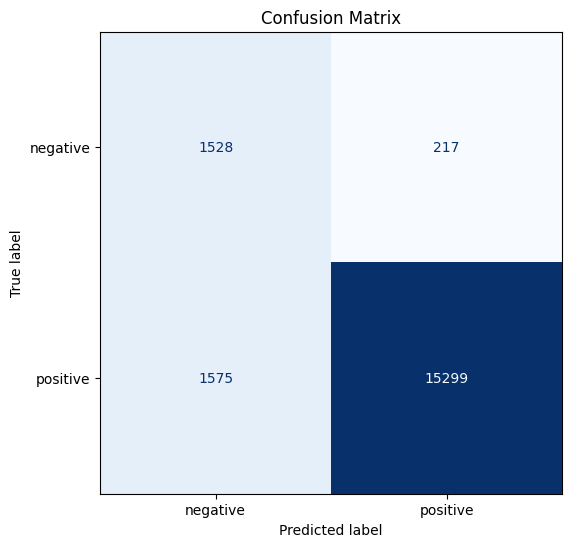

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_final = (y_probs > 0.5).astype(int)

cm = confusion_matrix(y_test_binary, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.savefig("../results/figures/confusion_matrix.png", bbox_inches="tight", dpi=200)
plt.show()

## Error Analysis
### Objective
While evaluation metrics such as accuracy and F1-score provide a high level of performance, they do not explain "why" the models fail in the specific cases.

The goal of this section is to:
- Identify misclassified reviews
- Analyze patterns in model errors
- Understand limitations of TF-IDF + Logistic Regression

This step is critical for diagnosing model weaknesses and improving real-world reliability.

In [14]:
import pandas as pd
y_prob = model_balanced.predict_proba(x_test_tfidf)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
y_test_binary = y_test.map({"positive": 1, "negative": 0})
results_df = pd.DataFrame({
    "reviewText": x_test.reset_index(drop=True),
    "true_label": y_test_binary.reset_index(drop=True),
    "predicted_label": y_pred,
    "predicted_probability": y_prob
})
misclassified = results_df[results_df["true_label"] != results_df["predicted_label"]].copy()
print("Total misclassified reviews:", len(misclassified))

Total misclassified reviews: 1792


### Method

To analyze model failures, I first compute predicted probabilities for the positive class and convert them into binary predictions using a threshold of 0.5.

Then, I construct a dataframe containing:
- the original review text,
- the true label,
- the predicted label,
- and the predicted probability.

This makes it possible to inspect model errors directly.


In [15]:
false_positives = misclassified[(misclassified["true_label"] == 0) & (misclassified["predicted_label"] == 1)].copy()
false_negatives = misclassified[(misclassified["true_label"] == 1) & (misclassified["predicted_label"] == 0)].copy()
false_positives = false_positives.sort_values(by="predicted_probability", ascending=False)
false_negatives = false_negatives.sort_values(by="predicted_probability", ascending=True)
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 217
False Negatives: 1575


### Error Categories

The misclassified reviews are divided into:

- **False Positives**: reviews that are actually negative but predicted as positive
- **False Negatives**: reviews that are actually positive but predicted as negative

I sort the errors by prediction confidence so that the most confident mistakes can be inspected first.


In [16]:
print("TOP FALSE POSITIVES:")
display(false_positives.head(20))
print("\nTOP FALSE NEGATIVES:")
display(false_negatives.head(20))

TOP FALSE POSITIVES:


,reviewText,true_label,predicted_label,predicted_probability
8697,works great,0,1,0.999999
5067,good,0,1,0.995388
3703,good,0,1,0.995388
16801,"Its works on and off, the main cable has a swe...",0,1,0.990678
7535,as described,0,1,0.988381
7133,I've seen this and other adapters in action. ...,0,1,0.984802
16294,I am torn on this purchase. My radio is in a J...,0,1,0.969350
9589,It fits so awkwardly.,0,1,0.967693
8796,I wanted a macro lens that would also be good ...,0,1,0.967206
6585,used these on a safari on Africa. They are li...,0,1,0.959746



TOP FALSE NEGATIVES:


,reviewText,true_label,predicted_label,predicted_probability
698,Didn't charge the phone .had to have a new pho...,1,0,0.001198
18407,Poor quality,1,0,0.001599
13534,Unit defective returned,1,0,0.001704
6991,"Amazon recommended this product. However, it w...",1,0,0.002041
8118,not bad but doesnt stay in place,1,0,0.002734
17176,"Wow, I ordered on a Sunday AM and the product ...",1,0,0.003225
13105,I broke the one that came with my large antenn...,1,0,0.003259
1651,"Purchased but returned, because I was able to ...",1,0,0.004842
6611,This was sent back because it was too small,1,0,0.006286
10106,This was sent back because it was too small,1,0,0.006286


### Manual Inspection

After extracting the most confident misclassifications, I manually inspect them to identify recurring error patterns.

Common error categories include:
- negation,
- mixed sentiment,
- ambiguous wording,
- weak sentiment expression,
- and context-dependent meaning.

In [17]:
sample_errors = pd.concat([false_positives.head(20), false_negatives.head(20)]).copy()
sample_errors["error_type"] = ""
sample_errors

,reviewText,true_label,predicted_label,predicted_probability,error_type
8697,works great,0,1,0.999999,
5067,good,0,1,0.995388,
3703,good,0,1,0.995388,
16801,"Its works on and off, the main cable has a swe...",0,1,0.990678,
7535,as described,0,1,0.988381,
7133,I've seen this and other adapters in action. ...,0,1,0.984802,
16294,I am torn on this purchase. My radio is in a J...,0,1,0.969350,
9589,It fits so awkwardly.,0,1,0.967693,
8796,I wanted a macro lens that would also be good ...,0,1,0.967206,
6585,used these on a safari on Africa. They are li...,0,1,0.959746,


In [18]:


sample_errors.loc[8697, "error_type"] = "weak_negative"     
sample_errors.loc[5067, "error_type"] = "weak_negative"      
sample_errors.loc[3703, "error_type"] = "weak_negative"      

sample_errors.loc[16801, "error_type"] = "mixed_sentiment"   
sample_errors.loc[7133, "error_type"] = "context_dependent"

sample_errors.loc[16294, "error_type"] = "mixed_sentiment"   
sample_errors.loc[9589, "error_type"] = "clear_negative"     

sample_errors.loc[8796, "error_type"] = "context_dependent"
sample_errors.loc[6585, "error_type"] = "weak_positive"
sample_errors.loc[18344, "error_type"] = "context_dependent"

sample_errors.loc[4285, "error_type"] = "mixed_sentiment"
sample_errors.loc[7645, "error_type"] = "weak_positive"
sample_errors.loc[15723, "error_type"] = "weak_positive"
sample_errors.loc[7535, "error_type"] = "ambiguous"
sample_errors.loc[16391, "error_type"] = "context_dependent"
sample_errors.loc[3082, "error_type"] = "weak_positive"
sample_errors.loc[3407, "error_type"] = "weak_positive"
sample_errors.loc[6575, "error_type"] = "mixed_sentiment"
sample_errors.loc[4169, "error_type"] = "weak_negative"
sample_errors.loc[5480, "error_type"] = "ambiguous"



sample_errors.loc[698, "error_type"] = "clear_negative"      
sample_errors.loc[18407, "error_type"] = "clear_negative"    
sample_errors.loc[13534, "error_type"] = "clear_negative"  

sample_errors.loc[6991, "error_type"] = "mixed_sentiment"    
sample_errors.loc[8118, "error_type"] = "negation"           

sample_errors.loc[17176, "error_type"] = "context_dependent"
sample_errors.loc[13105, "error_type"] = "clear_negative"

sample_errors.loc[1651, "error_type"] = "mixed_sentiment"
sample_errors.loc[6611, "error_type"] = "clear_negative"
sample_errors.loc[10106, "error_type"] = "clear_negative"

sample_errors.loc[11228, "error_type"] = "context_dependent"
sample_errors.loc[15826, "error_type"] = "negation"          

sample_errors.loc[4692, "error_type"] = "context_dependent"
sample_errors.loc[12171, "error_type"] = "clear_negative"

sample_errors.loc[4166, "error_type"] = "ambiguous"
sample_errors.loc[3404, "error_type"] = "ambiguous"

sample_errors.loc[7451, "error_type"] = "clear_negative"
sample_errors.loc[2516, "error_type"] = "context_dependent"

sample_errors.loc[15912, "error_type"] = "mixed_sentiment"
sample_errors.loc[10614, "error_type"] = "mixed_sentiment"


sample_errors

,reviewText,true_label,predicted_label,predicted_probability,error_type
8697,works great,0,1,0.999999,weak_negative
5067,good,0,1,0.995388,weak_negative
3703,good,0,1,0.995388,weak_negative
16801,"Its works on and off, the main cable has a swe...",0,1,0.990678,mixed_sentiment
7535,as described,0,1,0.988381,ambiguous
7133,I've seen this and other adapters in action. ...,0,1,0.984802,context_dependent
16294,I am torn on this purchase. My radio is in a J...,0,1,0.969350,mixed_sentiment
9589,It fits so awkwardly.,0,1,0.967693,clear_negative
8796,I wanted a macro lens that would also be good ...,0,1,0.967206,context_dependent
6585,used these on a safari on Africa. They are li...,0,1,0.959746,weak_positive


In [19]:
sample_errors["error_type"].value_counts()  

error_type
clear_negative       9
mixed_sentiment      8
context_dependent    8
weak_positive        5
weak_negative        4
ambiguous            4
negation             2
Name: count, dtype: int64

### Error Pattern Analysis

Based on manual annotation of misclassified samples, several key error patterns emerge:

1. **Label noise from rating-based supervision (most frequent)**
   A significant portion of errors fall into the *clear_negative* category. These are cases where the review text is clearly negative (e.g., "poor quality", "defective"), but the label is positive due to high star ratings.
   
   This indicates that the dataset contains weak supervision noise, where ratings do not always align with textual sentiment.

2. **Mixed sentiment (8 cases)**
   Reviews containing both positive and negative opinions are difficult for the model to classify correctly. Since TF-IDF treats words independently, it cannot determine which sentiment dominates.

3. **Context-dependent meaning (8 cases)**
   Many errors require understanding the full sentence or discourse structure (e.g., "however", "but"). The bag-of-words representation cannot capture such relationships.

4. **Weak sentiment signals (9 cases combined)**
   Weak expressions such as "good", "okay", or "not the best" provide insufficient lexical signals, leading to misclassification.

5. **Ambiguity (4 cases)**
   Some reviews do not clearly express sentiment, making them inherently difficult to classify.

6. **Negation (2 cases)**
   Although less frequent, negation remains a known challenge (e.g., "not bad"), as TF-IDF cannot model word interactions.



### Key Takeaways

- The model is not only limited by its architecture (TF-IDF + Logistic Regression), but also by the **quality of supervision**.
- Many errors are not purely model failures, but stem from **mismatch between rating-based labels and textual sentiment**.
- Capturing **context, negation, and sentence structure** would likely require more advanced models such as LSTM or Transformer-based architectures.

Overall, this analysis highlights the importance of both **model choice** and **data quality** in sentiment classification tasks.

## Baseline Model: Multinomial Naive Bayes

To contextualize the performance of Logistic Regression, I trained a Multinomial Naive Bayes baseline on the same TF-IDF features.

This provides a lightweight benchmark for sparse text classification and helps evaluate whether Logistic Regression offers meaningful improvement.

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
nb_model = MultinomialNB()
nb_model.fit(x_train_tfidf, y_train)
y_pred_nb = nb_model.predict(x_test_tfidf)
print("MultinomialNB Classification Report:")
print(classification_report(y_test, y_pred_nb))


MultinomialNB Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.11      0.20      1745
    positive       0.92      1.00      0.96     16874

    accuracy                           0.92     18619
   macro avg       0.92      0.56      0.58     18619
weighted avg       0.92      0.92      0.88     18619



In [21]:
y_pred_nb_binary = pd.Series(y_pred_nb).map({"positive": 1, "negative": 0}).values

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Multinomial Naive Bayes"],
    "Precision": [
        precision_score(y_test_binary, y_pred),
        precision_score(y_test_binary, y_pred_nb_binary)
    ],
    "Recall": [
        recall_score(y_test_binary, y_pred),
        recall_score(y_test_binary, y_pred_nb_binary)
    ],
    "F1-score": [
        f1_score(y_test_binary, y_pred),
        f1_score(y_test_binary, y_pred_nb_binary)
    ]
})

comparison_df

,Model,Precision,Recall,F1-score
0,Logistic Regression,0.986014,0.906661,0.944674
1,Multinomial Naive Bayes,0.915847,0.999052,0.955642


### Model Comparison Insights

Although Multinomial Naive Bayes achieves a slightly higher F1-score, a deeper analysis reveals important limitations.

Naive Bayes achieves **near-perfect recall (≈1.00)** for the positive class, but performs extremely poorly on the negative class (recall ≈ 0.11). This indicates that the model is heavily biased toward predicting the majority class.

This behavior is largely driven by **class imbalance** in the dataset, where positive reviews significantly outnumber negative ones.

As a result:
- Naive Bayes tends to classify almost all samples as positive
- This artificially inflates recall and F1-score for the positive class

In contrast, Logistic Regression provides a more balanced performance:
- Better handling of minority class (negative reviews)
- More reliable decision boundaries

---

### Key Takeaway

A higher F1-score does not necessarily indicate a better model.

Logistic Regression is preferred because it provides a more balanced and interpretable performance, while Naive Bayes is overly influenced by class imbalance.

## Precision-Recall Trade-off
In classification tasks, especially with imbalanced data, accuracy alone is not sufficient.

The Precision-Recall curve helps visualize the trade-off between:
- Precision (how accurate positive predictions are)
- Recall (how many actual positives are captured)

This allows us to select an optimal threshold depending on the application.

In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds_to_test = np.arange(0.05, 0.96, 0.01)

results = []

for threshold in thresholds_to_test:
    y_pred_thresh = (y_probs >= threshold).astype(int)
    
    precision_val = precision_score(y_test_binary, y_pred_thresh, zero_division=0)
    recall_val = recall_score(y_test_binary, y_pred_thresh, zero_division=0)
    f1_val = f1_score(y_test_binary, y_pred_thresh, zero_division=0)
    accuracy_val = accuracy_score(y_test_binary, y_pred_thresh)
    
    results.append({
        "threshold": threshold,
        "precision": precision_val,
        "recall": recall_val,
        "f1": f1_val,
        "accuracy": accuracy_val
    })

threshold_results = pd.DataFrame(results)

threshold_results.head()

,threshold,precision,recall,f1,accuracy
0,0.05,0.937218,0.996148,0.965785,0.936033
1,0.06,0.939823,0.994963,0.966607,0.937698
2,0.07,0.942456,0.993896,0.967493,0.939470
3,0.08,0.944645,0.993126,0.968279,0.941028
4,0.09,0.947088,0.991822,0.968939,0.942371


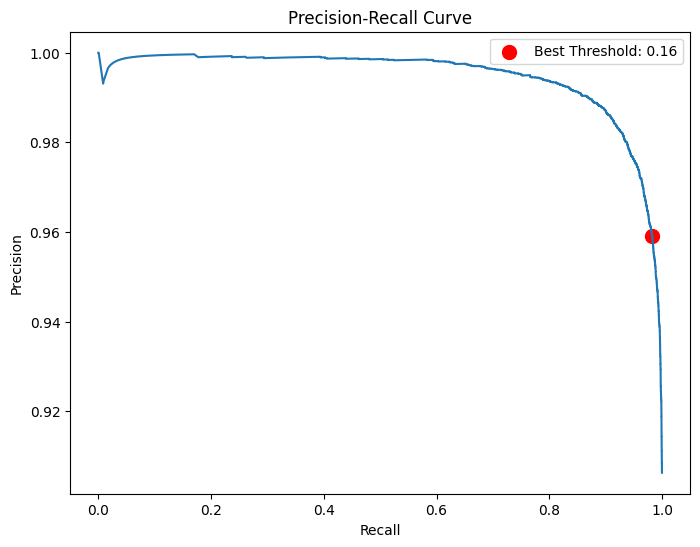

In [24]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np


precision, recall, thresholds = precision_recall_curve(y_test_binary, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)


best_threshold = threshold_results.loc[threshold_results["f1"].idxmax(), "threshold"]


idx = np.argmin(np.abs(thresholds - best_threshold))


plt.scatter(
    recall[idx + 1],
    precision[idx + 1],
    color='red',
    s=100,
    label=f'Best Threshold: {best_threshold:.2f}'
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.savefig("../results/figures/pr_curve.png", dpi=300, bbox_inches="tight")

plt.show()

### Optimal Operating Point

The red point on the Precision–Recall curve represents the threshold that maximizes the F1-score.

This point provides the best balance between precision and recall, indicating the most effective trade-off for this model.

It highlights that the optimal decision boundary is significantly lower than the default threshold of 0.5.

In [25]:
import numpy as np
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print ("Best Threshold: ", best_threshold)
print ("Best F1 Score: ", f1_scores[best_idx])


Best Threshold:  0.1570079328944199
Best F1 Score:  0.9708817417778735


In [26]:
from sklearn.metrics import classification_report
y_pred_new = (y_probs >= best_threshold).astype(int)
print(classification_report(y_test_binary, y_pred_new))

              precision    recall  f1-score   support

           0       0.78      0.59      0.68      1745
           1       0.96      0.98      0.97     16874

    accuracy                           0.95     18619
   macro avg       0.87      0.79      0.82     18619
weighted avg       0.94      0.95      0.94     18619



### Threshold Optimization and Trade-off Analysis
The default classification threshold of 0.5 is not optimal for this task.

By analyzing the Precision-Recall curve, the optimal threshold was found to be 0.157, which maximizes the F1-score.

This adjustment significantly changes the model's behavior:
- **Recall for the positive class increased to 0.98**, meaning the model captures nearly all positive reviews.
- However, **recall for the negative class dropped to 0.59**, indicating that more negative reviews are misclassified as positive.

This demonstrates a clear trade-off:
- Lower thresholds make the model more **aggressive** in predicting positives
- Higher thresholds make the model more **conservative**

In this case, the model prioritizes **recall over precision** for the positive class, which may be desirable depending on the application.

### Practical Implications 

The choice of threshold should depend on the real-world objective:

- If missing positive reviews is costly → use lower threshold (high recall)
- If false positives are costly → use higher threshold (high precision)

This highlights that model performance is not only determined by the model itself, but also by **decision threshold tuning**.

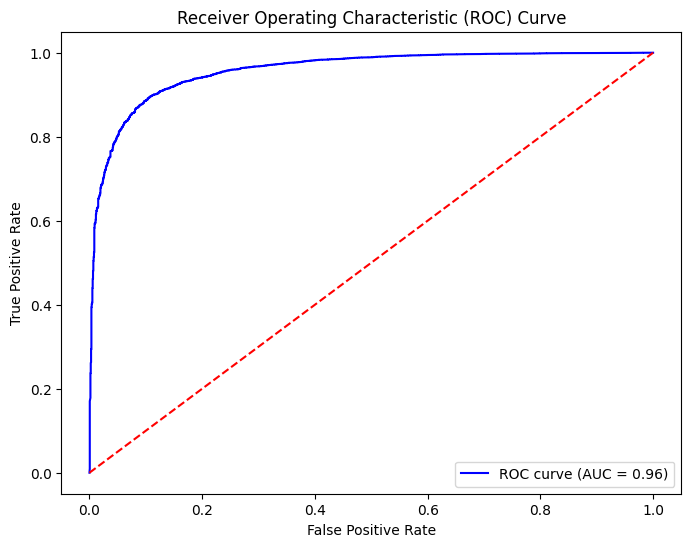

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr, tpr, roc_thresholds = roc_curve(y_test_binary, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.savefig("../results/figures/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

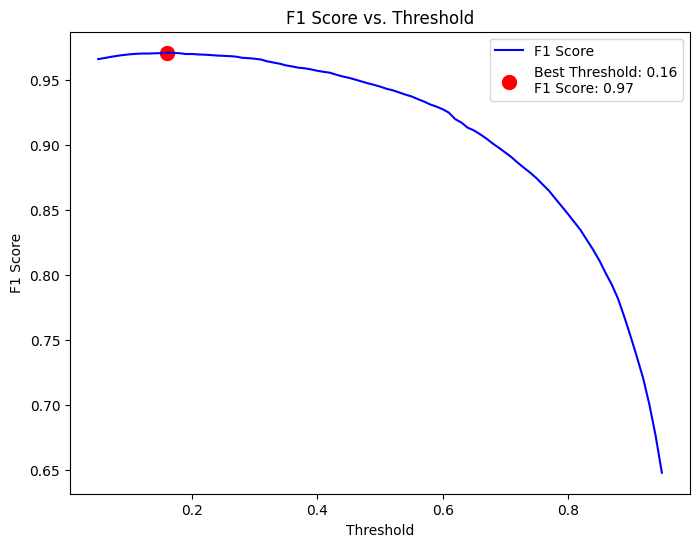

In [28]:
import matplotlib.pyplot as plt
best_idx = threshold_results["f1"].idxmax()
best_threshold = threshold_results.loc[best_idx, "threshold"]
best_f1 = threshold_results.loc[best_idx, "f1"]
plt.figure(figsize=(8, 6))
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1 Score", color="blue")
plt.scatter(best_threshold, best_f1, color="red", s=100, label=f"Best Threshold: {best_threshold:.2f}\nF1 Score: {best_f1:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold")
plt.savefig("../results/figures/threshold_vs_f1.png", dpi=300, bbox_inches="tight")
plt.legend()
plt.show()

In [29]:
threshold_results.to_csv("../results/tables/threshold_results.csv", index=False)

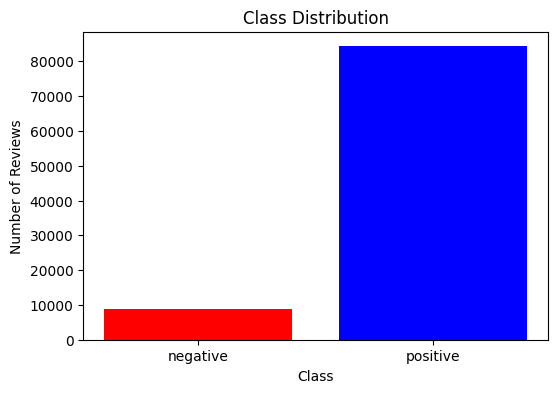

In [30]:
import matplotlib.pyplot as plt
label_counts = df["sentiment"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values, color=["red", "blue"])
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.title("Class Distribution")
plt.savefig("../results/figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

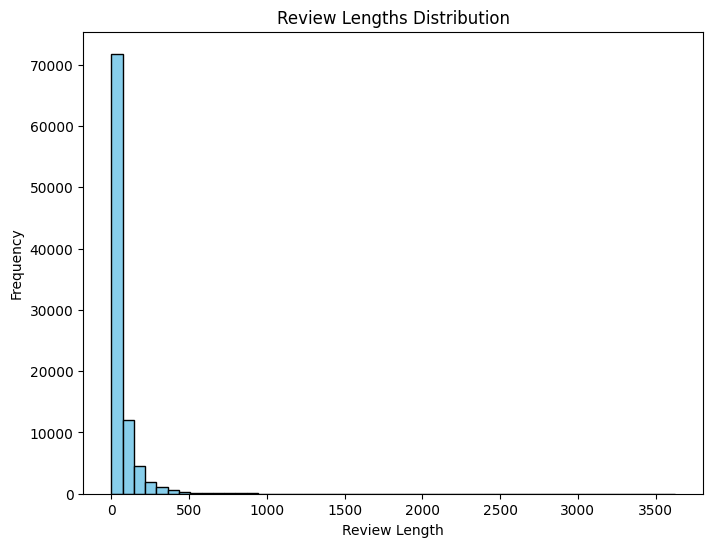

In [31]:
import matplotlib.pyplot as plt
df["review_length"] = df["reviewText"].astype(str).apply(lambda x: len(x.split()))
max_len = df["review_length"].quantile(0.99)
plt.figure(figsize=(8, 6))
plt.hist(df["review_length"], bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Lengths Distribution")
plt.savefig("../results/figures/review_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
import numpy as np
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
})

coef_df.head()

,word,weight
0,00,0.030529
1,000,0.134798
2,01,-0.094928
3,10,-0.999448
4,100,1.376008


In [36]:
top_positive = coef_df.sort_values(by="weight", ascending=False).head(20)
top_negative = coef_df.sort_values(by="weight", ascending=True).head(20)

top_positive.head(), top_negative.head()

(           word     weight
 1989      great  10.381047
 2593       love   6.541068
 4932      works   6.492708
 3148    perfect   6.300353
 1601  excellent   6.164925,
            word    weight
 2944        not -7.924729
 3266       poor -6.609025
 4697    useless -6.348785
 3668     return -6.027829
 3670  returning -5.693170)

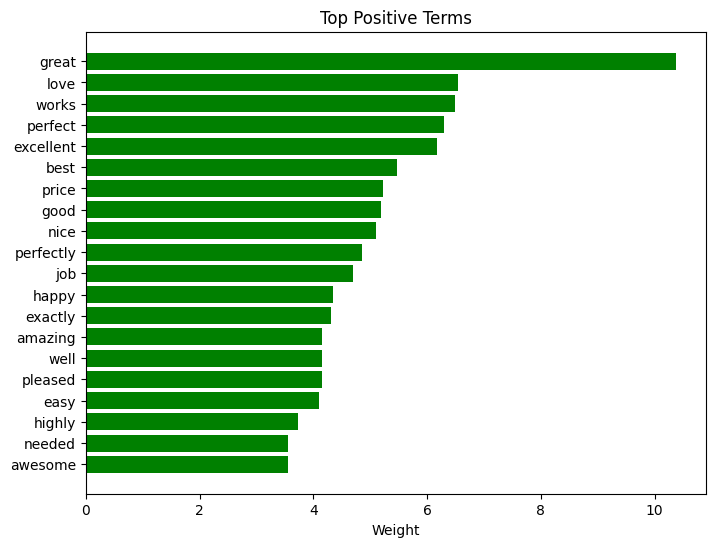

In [37]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(8, 6))
plt.barh(top_positive["word"], top_positive["weight"], color="green")
plt.gca().invert_yaxis()
plt.title("Top Positive Terms")
plt.xlabel("Weight")
plt.savefig("../results/figures/top_positive_terms.png", dpi=300, bbox_inches="tight")
plt.show()

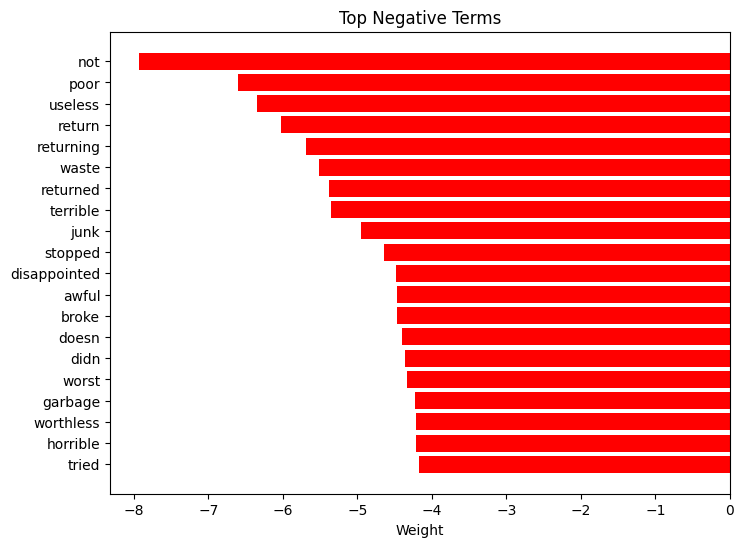

In [38]:
plt.figure(figsize=(8, 6))
plt.barh(top_negative["word"], top_negative["weight"], color="red")
plt.gca().invert_yaxis()
plt.title("Top Negative Terms")
plt.xlabel("Weight")
plt.savefig("../results/figures/top_negative_terms.png", dpi=300, bbox_inches="tight")
plt.show()